# 4. MODELADO

## 4.1 Introducción

En esta etapa se desarrollan modelos de aprendizaje automático con el objetivo de identificar patrones asociados al abandono escolar. Para ello, se emplean técnicas de segmentación y clasificación supervisada.

El modelo K-Means se utiliza como herramienta de análisis exploratorio para identificar grupos de estudiantes con características similares. Posteriormente, se implementan modelos supervisados como Redes Neuronales y Random Forest para realizar la predicción de abandono escolar utilizando la variable objetivo `Target_binary`.


In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt


## 4.2 Carga del dataset y preparación de variables

In [14]:
df = pd.read_csv('../data/processed/clean_dataset.csv')

df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target_binary
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


In [15]:
X = df.drop('Target_binary', axis=1)
y = df['Target_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (3539, 34)
Testing shape: (885, 34)


## 4.3 Modelo de segmentación K-Means

El algoritmo K-Means se utiliza para realizar un análisis de segmentación de estudiantes. Su propósito es identificar agrupamientos con características similares dentro del dataset y complementar el análisis exploratorio.


In [17]:
import warnings

# Limpieza y control de valores extremos para K-Means
X_train_kmeans = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_train_kmeans = X_train_kmeans.replace([np.inf, -np.inf], np.nan)
X_train_kmeans = X_train_kmeans.fillna(0)
X_train_kmeans = X_train_kmeans.clip(lower=-10, upper=10)
X_train_kmeans = X_train_kmeans.astype(np.float64)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10,
        init="random",
        algorithm="lloyd"
    )

    clusters = kmeans.fit_predict(X_train_kmeans)

print("Clusters generados correctamente")
print("Distribución de clusters:")
print(pd.Series(clusters).value_counts().sort_index())

Clusters generados correctamente
Distribución de clusters:
0    2603
1     231
2     705
Name: count, dtype: int64


## 4.4 Modelo supervisado: Red Neuronal

In [18]:
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20


/Users/hugotrejo/Desktop/student-dropout-ml-consulting/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5586 - loss: 0.7398 - val_accuracy: 0.7782 - val_loss: 0.4847
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - accuracy: 0.8338 - loss: 0.4180 - val_accuracy: 0.8164 - val_loss: 0.4083
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.8436 - loss: 0.3719 - val_accuracy: 0.8460 - val_loss: 0.3772
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.8711 - loss: 0.3359 - val_accuracy: 0.8630 - val_loss: 0.3581
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8790 - loss: 0.3055 - val_accuracy: 0.8630 - val_loss: 0.3553
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - accuracy: 0.8840 - loss: 0.3030 - val_accuracy: 0.8644 - val_loss: 0.3577
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - accuracy: 0.8773 - loss: 0.2943 - val_accuracy: 0.8602 - val_loss: 0.3569
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - accuracy: 0.8815 - loss: 0.2905 - val_accuracy: 0.8672 - val_loss

In [19]:
y_pred_nn = (model.predict(X_test_scaled) > 0.5).astype(int)

accuracy_nn = accuracy_score(y_test, y_pred_nn)

print("Neural Network Accuracy:", accuracy_nn)

print(classification_report(y_test, y_pred_nn))


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step
Neural Network Accuracy: 0.8757062146892656
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       601
           1       0.86      0.73      0.79       284

    accuracy                           0.88       885
   macro avg       0.87      0.84      0.85       885
weighted avg       0.87      0.88      0.87       885



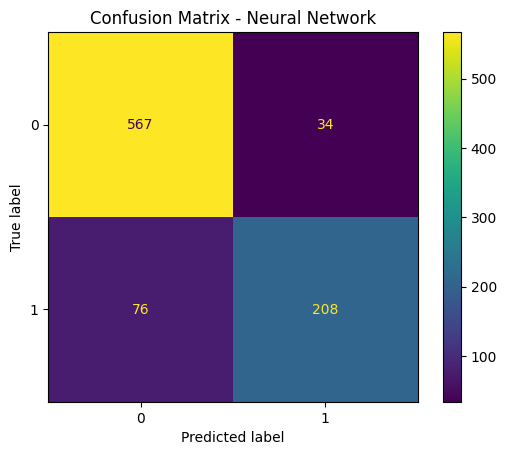

In [20]:
cm_nn = confusion_matrix(y_test, y_pred_nn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn)
disp.plot()

plt.title('Confusion Matrix - Neural Network')
plt.show()


## 4.5 Modelo supervisado: Random Forest

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.880225988700565
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       601
           1       0.87      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885



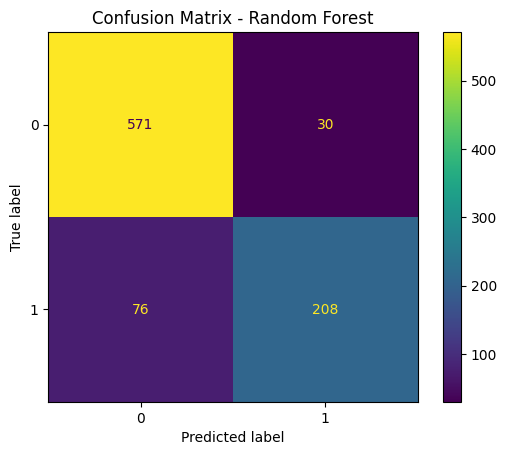

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()

plt.title('Confusion Matrix - Random Forest')
plt.show()


## 4.6 Comparación de modelos

Los modelos supervisados implementados mostraron un desempeño consistente en la predicción del abandono escolar. Tanto Random Forest como la Red Neuronal alcanzaron una precisión general cercana al 88%, lo cual indica una capacidad adecuada para clasificar estudiantes con y sin riesgo de abandono.

Random Forest obtuvo el mejor desempeño general, con un accuracy de 88.02%. Además, presentó un recall de 0.73 para la clase de abandono, lo que significa que logró identificar correctamente una proporción importante de los estudiantes que abandonaron sus estudios.

La Red Neuronal obtuvo un accuracy de 87.57%, con resultados muy cercanos a Random Forest. Este modelo también mostró un desempeño competitivo, especialmente considerando su capacidad para capturar relaciones no lineales entre las variables del dataset.

Por su parte, K-Means permitió identificar tres grupos de estudiantes con características similares. La distribución obtenida fue de 2603 estudiantes en el cluster 0, 231 estudiantes en el cluster 1 y 705 estudiantes en el cluster 2. Este análisis se utilizó como complemento exploratorio para apoyar la interpretación de perfiles estudiantiles, no como modelo principal de predicción.

En general, Random Forest se considera el modelo más adecuado para este proyecto debido a su desempeño ligeramente superior, estabilidad e interpretabilidad.

## 4.7 Conclusiones

Durante la etapa de modelado se implementaron técnicas supervisadas y no supervisadas para analizar el abandono escolar. Los modelos supervisados, Random Forest y Red Neuronal, fueron utilizados para predecir la variable objetivo `Target_binary`, mientras que K-Means se empleó como herramienta complementaria de segmentación exploratoria.

Los resultados muestran que ambos modelos supervisados alcanzaron un desempeño sólido, con una precisión cercana al 88%. Random Forest presentó el mejor resultado general, con un accuracy de 88.02%, seguido por la Red Neuronal con un accuracy de 87.57%.

La clase de abandono escolar presentó un recall cercano a 0.73 en ambos modelos, lo cual indica que los modelos lograron detectar una proporción relevante de estudiantes en riesgo. Este resultado es importante porque, en un contexto educativo, identificar estudiantes con probabilidad de abandono permite implementar acciones preventivas.

El análisis mediante K-Means permitió complementar el modelado al identificar tres grupos de estudiantes con características similares. Esta segmentación puede apoyar la interpretación posterior de perfiles de riesgo y facilitar recomendaciones institucionales.

En conclusión, Random Forest se selecciona como el modelo principal debido a su desempeño ligeramente superior, estabilidad y facilidad de interpretación. Sin embargo, la Red Neuronal también mostró resultados competitivos, por lo que ambos modelos son útiles para abordar el problema de predicción de abandono escolar.
